## Imports and load data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Load final dataset
df = pd.read_csv("../data/processed/match_data.csv")

# Convert date to datetime
df["date"] = pd.to_datetime(df["date"])

# Convert neutral to integer for modeling
df["neutral"] = df["neutral"].astype(int)

display(df.head())
print(df.shape)

,date,home_team,away_team,home_score,away_score,tournament,neutral,home_recent_win_rate,away_recent_win_rate,home_recent_goal_diff,away_recent_goal_diff,home_rank,away_rank,rank_difference,result
0,1993-01-20,Zambia,Namibia,4,0,FIFA World Cup qualification,0,1.0,0.0,2.0,-1.0,32.0,158.0,126.0,home_win
1,1993-01-31,Tunisia,Ethiopia,3,0,FIFA World Cup qualification,0,1.0,0.0,5.0,-1.0,38.0,85.0,47.0,home_win
2,1993-01-31,Zimbabwe,Angola,2,1,FIFA World Cup qualification,0,0.5,0.0,0.5,0.0,54.0,102.0,48.0,home_win
3,1993-01-31,Morocco,Benin,5,0,FIFA World Cup qualification,0,1.0,0.0,1.0,-5.0,41.0,127.0,86.0,home_win
4,1993-01-31,Egypt,Togo,3,0,FIFA World Cup qualification,0,0.0,0.0,0.0,-1.0,21.0,101.0,80.0,home_win


(7860, 15)


## Visualization 1: Match result distribution

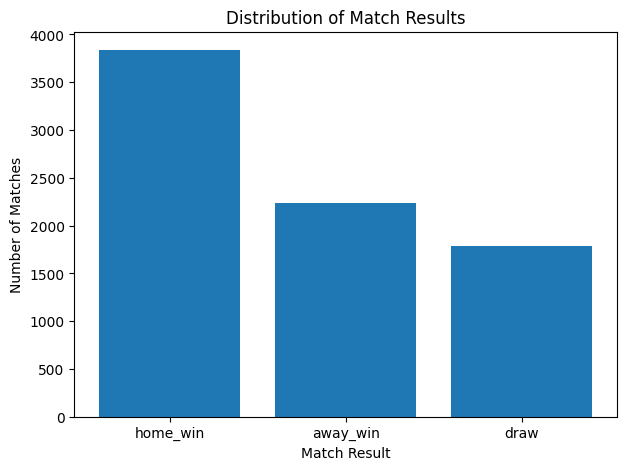

In [3]:
result_counts = df["result"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(result_counts.index, result_counts.values)
plt.title("Distribution of Match Results")
plt.xlabel("Match Result")
plt.ylabel("Number of Matches")
plt.show()

This plot shows that home wins are the most common outcome, followed by away wins and draws. This matters because our model has to predict three classes that are not perfectly balanced.

## Visualization 2: Rank difference vs home win rate

In [4]:
# Create binary column for whether home team won
df["home_win"] = (df["result"] == "home_win").astype(int)

# Create rank difference bins
df["rank_difference_bin"] = pd.cut(
    df["rank_difference"],
    bins=[-200, -100, -50, -25, 0, 25, 50, 100, 200],
    include_lowest=True
)

# Calculate home win rate by rank difference bin
rank_bin_summary = df.groupby("rank_difference_bin", observed=True).agg(
    home_win_rate=("home_win", "mean"),
    match_count=("home_win", "count")
).reset_index()

display(rank_bin_summary)

,rank_difference_bin,home_win_rate,match_count
0,"(-200.001, -100.0]",0.039474,304
1,"(-100.0, -50.0]",0.166832,1007
2,"(-50.0, -25.0]",0.256917,1012
3,"(-25.0, 0.0]",0.389601,1404
4,"(0.0, 25.0]",0.554090,1516
5,"(25.0, 50.0]",0.678540,1151
6,"(50.0, 100.0]",0.812004,1133
7,"(100.0, 200.0]",0.938838,327


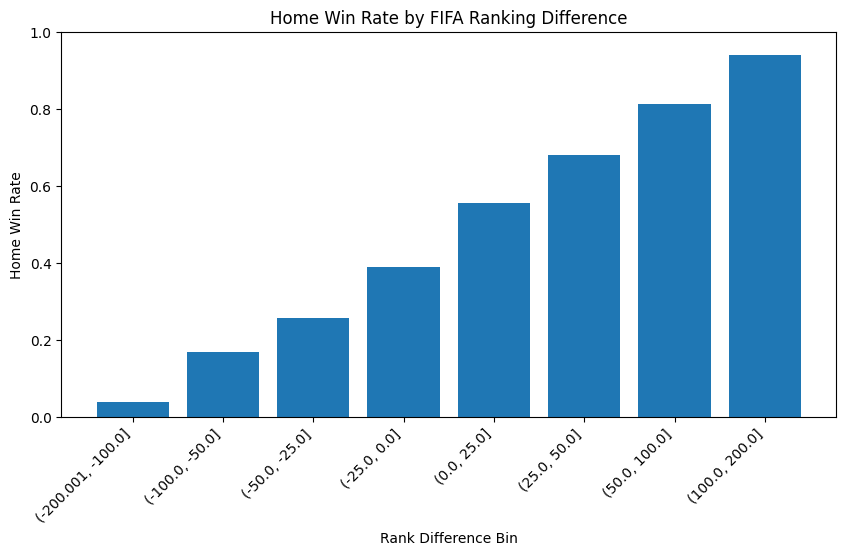

In [5]:
plt.figure(figsize=(10, 5))
plt.bar(
    rank_bin_summary["rank_difference_bin"].astype(str),
    rank_bin_summary["home_win_rate"]
)

plt.title("Home Win Rate by FIFA Ranking Difference")
plt.xlabel("Rank Difference Bin")
plt.ylabel("Home Win Rate")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.show()

We defined rank difference as away rank minus home rank. Since lower FIFA rank numbers are better, a positive rank difference means the home team is ranked better than the away team. The plot shows that as rank difference becomes more positive, the home team’s win rate generally increases.

## Visualization 3: Confusion matrix for model performance

In [6]:
features = [
    "home_recent_win_rate",
    "away_recent_win_rate",
    "home_recent_goal_diff",
    "away_recent_goal_diff",
    "home_rank",
    "away_rank",
    "rank_difference",
    "neutral"
]

target = "result"

# Sort by date for time-based split
df = df.sort_values("date").reset_index(drop=True)

X = df[features]
y = df[target]

# Time-based split using train_test_split without shuffling
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle=False
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
log_reg_model = LogisticRegression(max_iter=1000)
log_reg_model.fit(X_train_scaled, y_train)

# Predictions
train_preds = log_reg_model.predict(X_train_scaled)
test_preds = log_reg_model.predict(X_test_scaled)

# Accuracy
train_accuracy = accuracy_score(y_train, train_preds)
test_accuracy = accuracy_score(y_test, test_preds)

print("In-sample accuracy:", round(train_accuracy, 4))
print("Out-of-sample accuracy:", round(test_accuracy, 4))

In-sample accuracy: 0.608
Out-of-sample accuracy: 0.6107


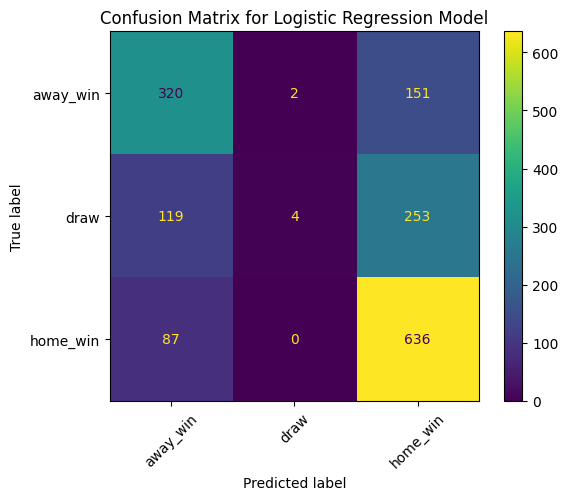

In [7]:
labels = log_reg_model.classes_

cm = confusion_matrix(y_test, test_preds, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title("Confusion Matrix for Logistic Regression Model")
plt.xticks(rotation=45)
plt.show()

The confusion matrix shows which match outcomes the model predicts correctly and where it struggles. This is useful because accuracy alone does not show whether the model is mostly predicting one class, such as home wins.

## Visualization 4: Logistic regression coefficients

In [8]:
coef_df = pd.DataFrame(
    log_reg_model.coef_,
    columns=features,
    index=log_reg_model.classes_
)

display(coef_df)

,home_recent_win_rate,away_recent_win_rate,home_recent_goal_diff,away_recent_goal_diff,home_rank,away_rank,rank_difference,neutral
away_win,0.101009,-0.103687,-0.266006,0.262899,0.285763,-0.237471,-0.460553,0.196843
draw,-0.013358,0.044274,0.049690,-0.000404,-0.014772,-0.042104,-0.024057,-0.029077
home_win,-0.087652,0.059413,0.216315,-0.262495,-0.270991,0.279574,0.484611,-0.167766


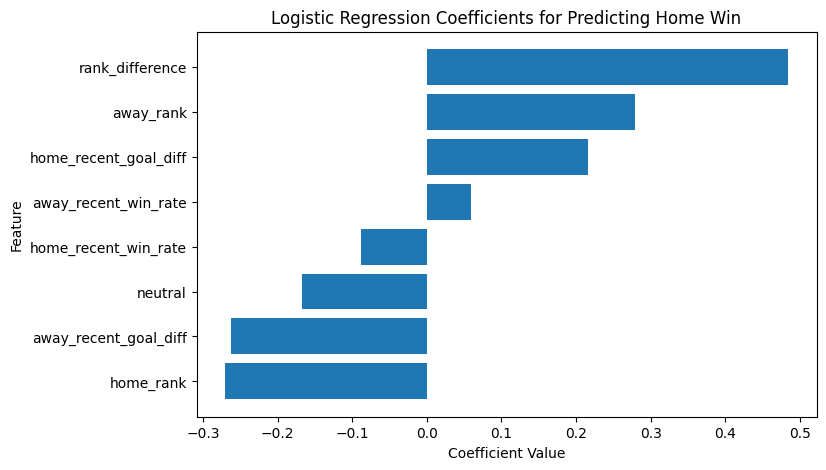

In [9]:
home_win_coefs = coef_df.loc["home_win"].sort_values()

plt.figure(figsize=(8, 5))
plt.barh(home_win_coefs.index, home_win_coefs.values)
plt.title("Logistic Regression Coefficients for Predicting Home Win")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

This plot shows which features increase or decrease the model’s likelihood of predicting a home win. Since the features were standardized, the coefficient sizes are more comparable. A positive coefficient increases the likelihood of predicting a home win, while a negative coefficient decreases it.

## Visualization 5: Train vs test accuracy

In [10]:
accuracy_df = pd.DataFrame({
    "Dataset": ["Training Set", "Testing Set"],
    "Accuracy": [train_accuracy, test_accuracy]
})

display(accuracy_df)

,Dataset,Accuracy
0,Training Set,0.607983
1,Testing Set,0.610687


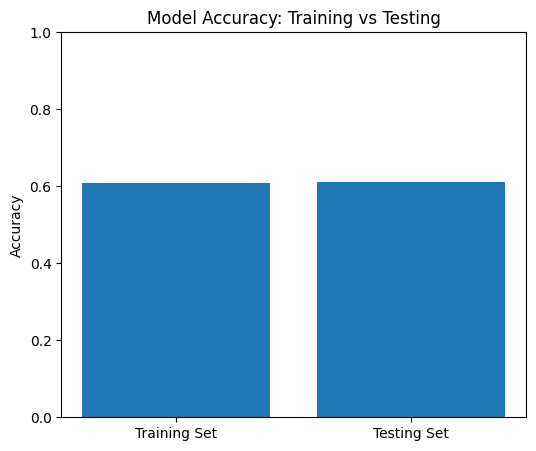

In [11]:
plt.figure(figsize=(6, 5))
plt.bar(accuracy_df["Dataset"], accuracy_df["Accuracy"])
plt.title("Model Accuracy: Training vs Testing")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

We compared training accuracy and testing accuracy to evaluate both in-sample and out-of-sample performance. The test accuracy is more important because it shows how the model performs on newer matches it did not train on.